In [1]:
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import glob
import numpy as np

In [219]:
def latlon_dist(lat, lon, lats, lons):

        #Calculate great circle distance (Harversine) between a lat lon point (lat, lon) and a list of lat lon
        # points (lats, lons)
                        
        R = 6373.0
                        
        lat1 = np.deg2rad(lat)
        lon1 = np.deg2rad(lon)
        lat2 = np.deg2rad(lats)
        lon2 = np.deg2rad(lons)
                
        dlon = lon2 - lon1
        dlat = lat2 - lat1

        a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
        c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

        return (R * c)

def plot_one_min_data(stn_id, v, event_time, ax, ls="-", color="tab:blue", marker=None, pad=2):
    
    for f in glob.glob("/g/data/eg3/ab4502/ExtremeWind/obs/aws/one_minute_case_data/HD01D_Data_"+stn_id+"_*.txt"):
        df = pd.read_csv(f,
                   names=["hd","stn_no","dt_lt","Time (UTC)","p","p_q","p_p","t","t1","dp","dp_q",\
                          "rh","rh_q","ws","ws_q","min_ws","min_ws_q","wd","wd_q","std_wd","std_wd_q",\
                          "wg","wg_q","mslp","mslp_q","pres","pres_q","qnh","qnh_q","#"], header=0, index_col="Time (UTC)", parse_dates=True)
        if np.min(np.abs(df.index - event_time)).seconds < 3600:
                if (stn_id == "090035") & (event_time.year==2020) & (event_time.month==1) & (event_time.day==31):
                    time = df.sort_values("wg").index[-2]
                else:
                    time = df.index[np.argmax(df.wg)]
                times = [time + dt.timedelta(seconds=-2*60*60), time + dt.timedelta(seconds=2*60*60)]
                df = df.loc[slice(times[0], times[1])]
                df = df.set_index(pd.DatetimeIndex(df.index))

                if v == "wg":
                    ax.set_ylim([0,55])
                    lab="Wind gust (m/s)"
                elif v == "wd":
                    ax.set_ylim([0,360])
                    lab="Direction from North (degrees)"
                elif v == "mslp":
                    ax.set_ylim([998,1020])   
                    lab="Mean sea-level pressure (hPa)"
                elif v == "dp":
                    ax.set_ylim([5,45])                     
                    lab="Dewpoint temperature (Celsius)"
                elif v == "t":
                    ax.set_ylim([5,45]) 
                    lab="Air temperature (Celsius)"                    
                elif v in ["p"]:
                    ax.set_ylim([0,40])                 
                    lab="Precipitation (mm)"
                if v == "p":
                    df[v] = pd.to_numeric(df[v], errors="coerce").cumsum()                   
                else:
                    df[v] = pd.to_numeric(df[v], errors="coerce").interpolate()                         
                line = ax.plot(df.index.to_pydatetime(), df[v].values, ls=ls, color=color, marker=marker, label=lab)
                ax.tick_params(axis='y', colors=color, pad=pad)
                ax.tick_params(axis='x', rotation=25)    
                ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
                ax.axvline(time, color="k", ls="--", lw=1)
                
                return line
        else:
                pass
   
def plot_driver(state, stn_id, t, rows, cols, num, title, legend=False):
    lightning = load_lightning(t.strftime("%Y%m%d"), stn_id, state)
    lightning = lightning.loc[(lightning.index>=(t + dt.timedelta(seconds=-2*60*60))) & (lightning.index <= t + dt.timedelta(seconds=2*60*60)),"latlon"]    
    ax1=plt.subplot(rows,cols,num)
    ax2=ax1.twinx()
    ax3=ax1.twinx()    
    line1=plot_one_min_data(stn_id, "wg", t, ax1)
    line2=plot_one_min_data(stn_id, "wd", t, ax2, color="tab:red", ls=":")
    line3=ax3.plot(lightning, color="tab:purple", lw=0.5, label="Lightning (1 min.)")
    ax3.tick_params(axis='y', colors="tab:purple", pad=30)
    ax3.set_ylim([-1,30])
    ax1.grid()
    ax1.set_title(title, loc="left")
    if legend:
        plt.legend((line1[0], line2[0], line3[0]), (line1[0].get_label(), line2[0].get_label(),line3[0].get_label()),
                   loc=3, bbox_to_anchor=(-0.05,-0.8), ncol=3)

    ax1=plt.subplot(rows,cols,num+1)
    ax2=ax1.twinx()
    ax3=ax1.twinx()    
    line1=plot_one_min_data(stn_id, "t", t, ax1)
    line2=plot_one_min_data(stn_id, "dp", t, ax1, ls="--")
    line3=plot_one_min_data(stn_id, "mslp", t, ax2, color="tab:red", ls=":")
    line4=plot_one_min_data(stn_id, "p", t, ax3, color="tab:green", ls=":", pad=40)    
    ax1.grid()
    if legend:
        plt.legend((line1[0], line2[0], line3[0], line4[0]), (line1[0].get_label(), line2[0].get_label(), line3[0].get_label(), line4[0].get_label()),
               loc=3, bbox_to_anchor=(0,-0.8), ncol=2)    
    
def load_lightning(date, stn_no, state):

    try:
        lightning = pd.read_csv("/g/data/eg3/ab4502/ExtremeWind/ad_data/lightning_raw/A"+date+".loc",header=None,
                               names=["date","time","lat","lon","1","2"])
    except:
        lightning = pd.read_csv("/g/data/eg3/ab4502/ExtremeWind/ad_data/lightning_raw/AE"+date+".loc",header=None,
                               names=["date","time","lat","lon","1","2","3","4","5"])
    names = ["id", "stn_no", "district", "stn_name", "site_open", "site_close", "lat", "lon", "latlon_method", "state",\
                    "hgt_asl", "hgt_asl_baro", "wmo_idx", "y1", "y2", "comp%", "Y%", "N%", "W%", "S%", "I%", "#"]
    stn_df = pd.read_csv(glob.glob("/g/data/eg3/ab4502/ExtremeWind/obs/aws/"+state+"_one_min_gust/HD01D_StnDet_*.txt")[0],\
            names=names, header=0)
    lightning["l_dist"] = latlon_dist(stn_df[stn_df.stn_no==int(stn_no)].lat.values[0], stn_df[stn_df.stn_no==int(stn_no)].lon.values[0],
        lightning["lat"], lightning["lon"])
    lightning["latlon"] = lightning["lat"].astype("str") + " " + lightning["lon"].astype("str")
    lightning["latlon"] = lightning.latlon.where(lightning.l_dist <= 50, np.nan)

    lightning["datetime"] = pd.DatetimeIndex(lightning["date"] + " " + lightning["time"])
    lightning = lightning.set_index(lightning["datetime"])    
    return lightning[["lat","lon","l_dist","latlon"]].resample("1min").nunique()    

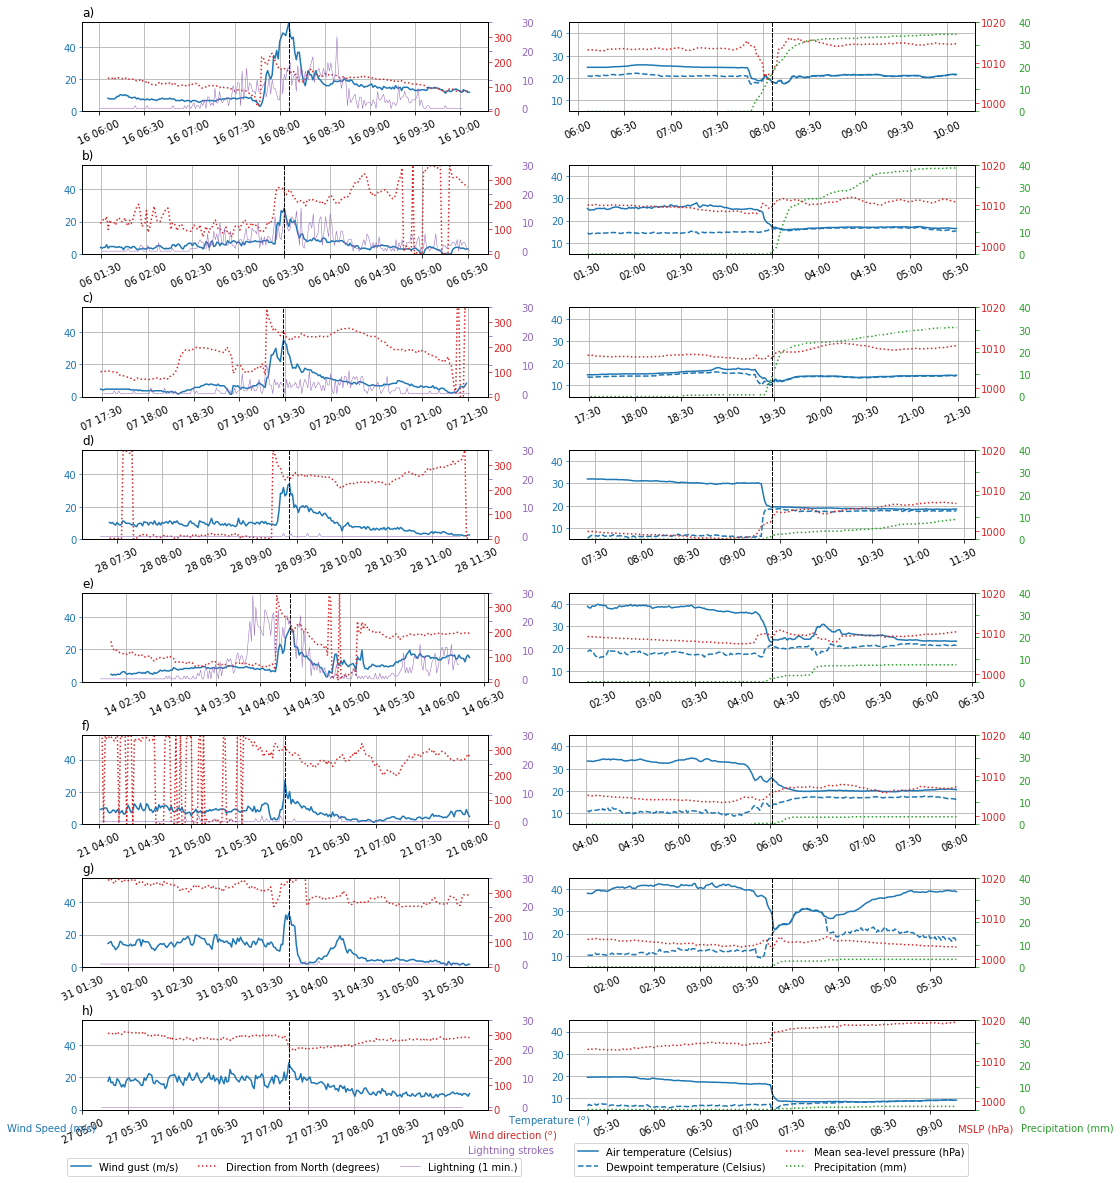

In [220]:
fig = plt.figure(figsize=[16,20])

rows = 8; cols = 2
t = dt.datetime(2006,12,16,8,1); state="qld"; stn_id = "040068"; plot_driver(state, stn_id, t, rows, cols, 1, "a)")
t = dt.datetime(2010,3,6,3,31); state="vic"; stn_id = "086282"; plot_driver(state, stn_id, t, rows, cols, 3, "b)")
t = dt.datetime(2011,10,7,19,31); state="qld"; stn_id = "041359"; plot_driver(state, stn_id, t, rows, cols, 5, "c)")
t = dt.datetime(2015,2,28,9,19); state="vic"; stn_id = "086282"; plot_driver(state, stn_id, t, rows, cols, 7, "d)")
t = dt.datetime(2016,1,14,4,13); state="nsw"; stn_id = "066037"; plot_driver(state, stn_id, t, rows, cols, 9, "e)")
t = dt.datetime(2016,11,21,6,1); state="vic"; stn_id = "087168"; plot_driver(state, stn_id, t, rows, cols, 11, "f)")
t = dt.datetime(2020,1,31,3,42); state="vic"; stn_id = "090035"; plot_driver(state, stn_id, t, rows, cols, 13, "g)")
t = dt.datetime(2020,8,27,7,12); state="vic"; stn_id = "087113"; plot_driver(state, stn_id, t, rows, cols, 15, "h)",legend=True)

plt.subplots_adjust(hspace=0.6)

plt.text(0.06,0.11,"Wind Speed (m/s)",transform=fig.transFigure, rotation=0, color="tab:blue")
plt.text(0.46,0.105,"Wind direction ($^{o}$)",transform=fig.transFigure, rotation=0, color="tab:red")
plt.text(0.495,0.115,"Temperature ($^{o}$)",transform=fig.transFigure, rotation=0, color="tab:blue")
plt.text(0.885,0.11,"MSLP (hPa)",transform=fig.transFigure, rotation=0, color="tab:red")
plt.text(0.94,0.11,"Precipitation (mm)",transform=fig.transFigure, rotation=0, color="tab:green")
plt.text(0.46,0.095,"Lightning strokes",transform=fig.transFigure, rotation=0, color="tab:purple")

plt.savefig("/g/data/eg3/ab4502/figs/ExtremeWind/case_studies/one_min_obs.jpeg", quality=100, bbox_inches="tight")

In [193]:
date = dt.datetime(2020,1,31,3,42).strftime("%Y%m%d"); state="vic"; stn_id = "090035"
#lightning = load_lightning(t.strftime("%Y%m%d"), stn_id, state)
#lightning.loc[slice(t + dt.timedelta(seconds=-2*60*60), t + dt.timedelta(seconds=2*60*60))]
#lightning = lightning.loc[(lightning.index>=(t + dt.timedelta(seconds=-2*60*60))) & (lightning.index <= t + dt.timedelta(seconds=2*60*60)),"latlon"]    
try:
    lightning = pd.read_csv("/g/data/eg3/ab4502/ExtremeWind/ad_data/lightning_raw/A"+date+".loc",header=None,
                           names=["date","time","lat","lon","1","2"])
except:
    lightning = pd.read_csv("/g/data/eg3/ab4502/ExtremeWind/ad_data/lightning_raw/AE"+date+".loc",header=None,
                           names=["date","time","lat","lon","1","2","3","4","5"])
names = ["id", "stn_no", "district", "stn_name", "site_open", "site_close", "lat", "lon", "latlon_method", "state",\
                "hgt_asl", "hgt_asl_baro", "wmo_idx", "y1", "y2", "comp%", "Y%", "N%", "W%", "S%", "I%", "#"]
stn_df = pd.read_csv(glob.glob("/g/data/eg3/ab4502/ExtremeWind/obs/aws/"+state+"_one_min_gust/HD01D_StnDet_*.txt")[0],\
        names=names, header=0)
lightning["l_dist"] = latlon_dist(stn_df[stn_df.stn_no==int(stn_no)].lat.values[0], stn_df[stn_df.stn_no==int(stn_no)].lon.values[0],
    lightning["lat"], lightning["lon"])
lightning["latlon"] = lightning["lat"].astype("str") + " " + lightning["lon"].astype("str")
lightning["latlon"] = lightning.latlon.where(lightning.l_dist <= 50, np.nan)

lightning["datetime"] = pd.DatetimeIndex(lightning["date"] + " " + lightning["time"])
lightning = lightning.set_index(lightning["datetime"])    
return lightning[["lat","lon","l_dist","latlon"]].resample("1min").nunique()

In [194]:
lightning[["lat","lon","l_dist","latlon"]].resample("1min").nunique()

,lat,lon,l_dist,latlon
datetime,,,,
2020-01-31 00:00:00,434,438,438,0
2020-01-31 00:01:00,421,421,423,0
2020-01-31 00:02:00,461,461,462,0
2020-01-31 00:03:00,450,451,452,0
2020-01-31 00:04:00,481,482,482,0
...,...,...,...,...
2020-01-31 23:55:00,509,507,512,0
2020-01-31 23:56:00,487,485,492,0
2020-01-31 23:57:00,468,469,471,0
